References of Youtube Videos:


*   https://www.youtube.com/watch?v=3RAEwPiZkkw
*   https://www.youtube.com/watch?v=3dhcmeOTZ_Q
*   https://www.youtube.com/watch?v=ZVR2Way4nwQ



In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

In [ ]:
data = {
    'Outlook':    ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                   'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Humidity':   ['High', 'High', 'High', 'High', 'Medium', 'Medium', 'Medium',
                   'High', 'Low', 'Medium', 'Medium', 'High', 'Medium', 'High'],
    'Wind':       ['Weak', 'Strong', 'Weak', 'Weak', 'Normal', 'Strong', 'Strong',
                   'Weak', 'Normal', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Temperature':['Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild',
                   'Hot', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Cool'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

df

,Outlook,Humidity,Wind,Temperature,PlayTennis
0,Sunny,High,Weak,Hot,No
1,Sunny,High,Strong,Hot,No
2,Overcast,High,Weak,Mild,Yes
3,Rain,High,Weak,Cool,Yes
4,Rain,Medium,Normal,Cool,Yes
5,Rain,Medium,Strong,Cool,No
6,Overcast,Medium,Strong,Mild,Yes
7,Sunny,High,Weak,Hot,No
8,Sunny,Low,Normal,Mild,Yes
9,Rain,Medium,Weak,Cool,Yes


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

# Ordinal encoding for ordinal features
ordinal_encoder = OrdinalEncoder(categories=[
    ['Low', 'Medium', 'High'],        # Humidity
    ['Weak', 'Normal', 'Strong'],     # Wind
    ['Cool', 'Mild', 'Hot']           # Temperature
])

df[['Humidity', 'Wind', 'Temperature']] = ordinal_encoder.fit_transform(
    df[['Humidity', 'Wind', 'Temperature']]
)

# Label encoding for target
from sklearn.preprocessing import LabelEncoder
le_play = LabelEncoder()
df['PlayTennis'] = le_play.fit_transform(df['PlayTennis'])  # No=0, Yes=1

# One-hot encoding for nominal feature
df = pd.get_dummies(df, columns=['Outlook'], prefix='Outlook')

In [ ]:
df

,Humidity,Wind,Temperature,PlayTennis,Outlook_Overcast,Outlook_Rain,Outlook_Sunny
0,2.0,0.0,2.0,0,False,False,True
1,2.0,2.0,2.0,0,False,False,True
2,2.0,0.0,1.0,1,True,False,False
3,2.0,0.0,0.0,1,False,True,False
4,1.0,1.0,0.0,1,False,True,False
5,1.0,2.0,0.0,0,False,True,False
6,1.0,2.0,1.0,1,True,False,False
7,2.0,0.0,2.0,0,False,False,True
8,0.0,1.0,1.0,1,False,False,True
9,1.0,0.0,0.0,1,False,True,False


In [ ]:
X = df[['Humidity', 'Wind', 'Temperature', 'Outlook_Overcast', 'Outlook_Rain', 'Outlook_Sunny']]
y = df['PlayTennis']

In [ ]:
X

,Humidity,Wind,Temperature,Outlook_Overcast,Outlook_Rain,Outlook_Sunny
0,2.0,0.0,2.0,False,False,True
1,2.0,2.0,2.0,False,False,True
2,2.0,0.0,1.0,True,False,False
3,2.0,0.0,0.0,False,True,False
4,1.0,1.0,0.0,False,True,False
5,1.0,2.0,0.0,False,True,False
6,1.0,2.0,1.0,True,False,False
7,2.0,0.0,2.0,False,False,True
8,0.0,1.0,1.0,False,False,True
9,1.0,0.0,0.0,False,True,False


In [ ]:
y

,PlayTennis
0,0
1,0
2,1
3,1
4,1
5,0
6,1
7,0
8,1
9,1


In [ ]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

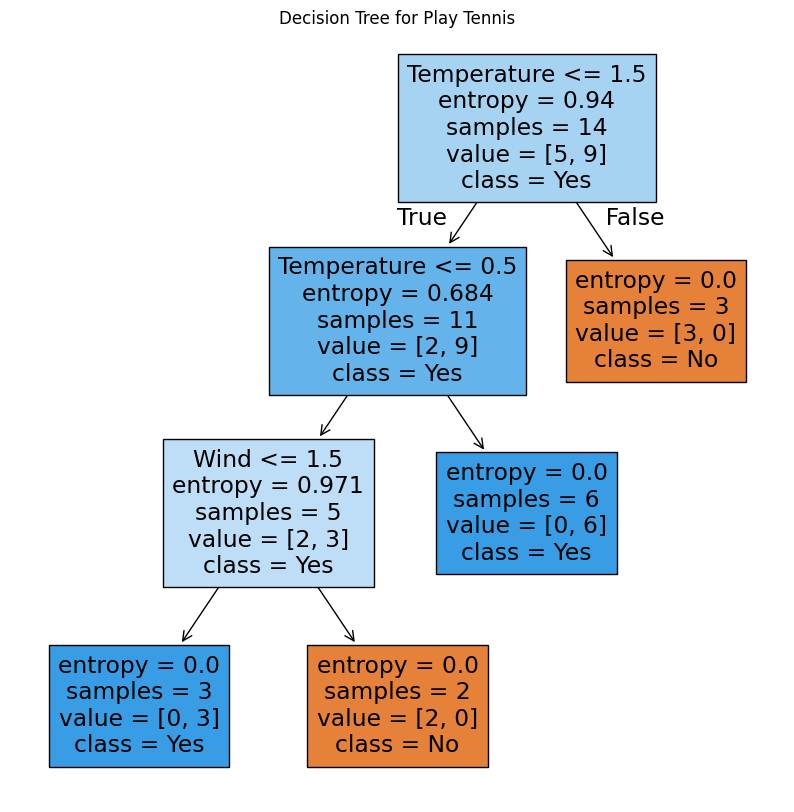

In [ ]:
plt.figure(figsize=(10, 10))
tree.plot_tree(model, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
plt.title("Decision Tree for Play Tennis")
plt.show()

In [ ]:
import pandas as pd

# Example input (change as needed)
outlook = 'Sunny'
humidity = 'Low'
wind = 'Weak'
temperature = 'Mild'

# Encode ordinal features
# Combine all ordinal features into a single 2D array for transformation
input_ordinal_features = pd.DataFrame([[humidity, wind, temperature]], columns=['Humidity', 'Wind', 'Temperature'])
encoded_ordinal_values = ordinal_encoder.transform(input_ordinal_features)

humidity_encoded = encoded_ordinal_values[0, 0]
wind_encoded = encoded_ordinal_values[0, 1]
temperature_encoded = encoded_ordinal_values[0, 2]

# Create one-hot encoding for 'Outlook'
outlook_features = {'Outlook_Overcast': 0, 'Outlook_Rain': 0, 'Outlook_Sunny': 0}
outlook_col = f"Outlook_{outlook}"
if outlook_col in outlook_features:
    outlook_features[outlook_col] = 1

# Combine all features into a single row
input_data = pd.DataFrame([{
    'Humidity': humidity_encoded,
    'Wind': wind_encoded,
    'Temperature': temperature_encoded,
    **outlook_features
}])

# Predict
prediction = model.predict(input_data)[0]
predicted_play = le_play.inverse_transform([prediction])[0]

print(f"Prediction for Outlook={outlook}, Humidity={humidity}, Wind={wind}, Temperature={temperature}: PlayTennis={predicted_play}")

Prediction for Outlook=Sunny, Humidity=Low, Wind=Weak, Temperature=Mild: PlayTennis=Yes


In [ ]:
from joblib import dump

filename = '/content/drive/MyDrive/JCAIEAH-003/Notes and Hands On/Modul 2/Day 2/finalized_model.joblib'
dump(model, filename)

['/content/drive/MyDrive/JCAIEAH-003/Notes and Hands On/Modul 2/Day 2/finalized_model.joblib']

In [ ]:
from joblib import load

loaded_model = load(filename)
loaded_model

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [ ]:
import pandas as pd

# Example input (change as needed)
outlook = 'Sunny'
humidity = 'Low'
wind = 'Weak'
temperature = 'Mild'

# Encode ordinal features
# Combine all ordinal features into a single 2D array for transformation
input_ordinal_features = pd.DataFrame([[humidity, wind, temperature]], columns=['Humidity', 'Wind', 'Temperature'])
encoded_ordinal_values = ordinal_encoder.transform(input_ordinal_features)

humidity_encoded = encoded_ordinal_values[0, 0]
wind_encoded = encoded_ordinal_values[0, 1]
temperature_encoded = encoded_ordinal_values[0, 2]

# Create one-hot encoding for 'Outlook'
outlook_features = {'Outlook_Overcast': 0, 'Outlook_Rain': 0, 'Outlook_Sunny': 0}
outlook_col = f"Outlook_{outlook}"
if outlook_col in outlook_features:
    outlook_features[outlook_col] = 1

# Combine all features into a single row
input_data = pd.DataFrame([{
    'Humidity': humidity_encoded,
    'Wind': wind_encoded,
    'Temperature': temperature_encoded,
    **outlook_features
}])

# Predict
prediction = loaded_model.predict(input_data)[0]
predicted_play = le_play.inverse_transform([prediction])[0]

print(f"Prediction for Outlook={outlook}, Humidity={humidity}, Wind={wind}, Temperature={temperature}: PlayTennis={predicted_play}")

Prediction for Outlook=Sunny, Humidity=Low, Wind=Weak, Temperature=Mild: PlayTennis=Yes
